# AI-Powered Retail Demand Forecasting and Inventory Optimization

## Notebook 03 — Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to perform an in-depth exploratory analysis
of the cleaned retail dataset.

The analysis focuses on identifying:

- Demand trends
- Time-series patterns
- Seasonality
- Store-level behaviour
- Product-level behaviour
- Regional differences
- Promotional effects
- Pricing effects
- Inventory-demand relationships
- Demand variability
- Potential forecasting features

The findings will be used to design the feature engineering and machine
learning pipeline in the next stage.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Cleaned Dataset

The cleaned dataset generated in Notebook 02 will be used for exploratory
analysis.

The original raw dataset will not be modified.

In [2]:
DATA_PATH = "../data/processed/cleaned_sales_data.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110


In [3]:
print("Dataset Information")
print("=" * 50)

print(f"Rows            : {len(df):,}")
print(f"Columns         : {len(df.columns)}")
print(f"Stores          : {df['Store ID'].nunique():,}")
print(f"Products        : {df['Product ID'].nunique():,}")
print(f"Categories      : {df['Category'].nunique():,}")
print(f"Regions         : {df['Region'].nunique():,}")
print(f"Dates           : {df['Date'].nunique():,}")

print(f"\nDate range:")
print(f"From            : {df['Date'].min()}")
print(f"To              : {df['Date'].max()}")

Dataset Information
Rows            : 76,000
Columns         : 16
Stores          : 5
Products        : 20
Categories      : 5
Regions         : 4
Dates           : 760

Date range:
From            : 2022-01-01 00:00:00
To              : 2024-01-30 00:00:00


## 2. Demand Distribution

Demand is the primary forecasting target.

Understanding its distribution helps us determine whether demand is:

- Approximately normally distributed
- Skewed
- Highly variable
- Dominated by extreme observations

In [4]:
print(df["Demand"].describe())

count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64


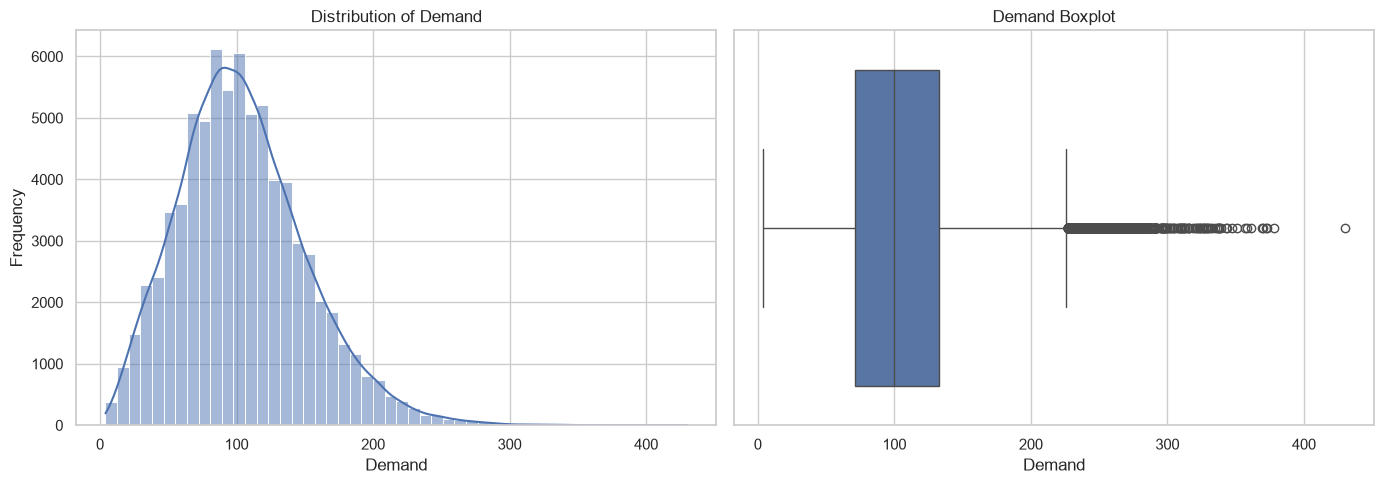

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Demand"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Demand")
axes[0].set_xlabel("Demand")
axes[0].set_ylabel("Frequency")

sns.boxplot(
    x=df["Demand"],
    ax=axes[1]
)

axes[1].set_title("Demand Boxplot")
axes[1].set_xlabel("Demand")

plt.tight_layout()
plt.show()

In [6]:
demand_stats = pd.DataFrame({
    "Mean": [df["Demand"].mean()],
    "Median": [df["Demand"].median()],
    "Std Dev": [df["Demand"].std()],
    "Minimum": [df["Demand"].min()],
    "Maximum": [df["Demand"].max()],
    "Skewness": [df["Demand"].skew()],
    "Kurtosis": [df["Demand"].kurtosis()]
})

demand_stats

,Mean,Median,Std Dev,Minimum,Maximum,Skewness,Kurtosis
0,104.317158,100.0,46.964801,4,430,0.607778,0.674937


## 3. Overall Demand Trend

Demand forecasting is a time-series problem.

We aggregate demand by date to identify the overall trend in retail demand.

In [7]:
daily_demand = (
    df.groupby("Date")["Demand"]
    .agg(["sum", "mean", "std"])
    .reset_index()
)

daily_demand.head()

,Date,sum,mean,std
0,2022-01-01,10060,100.60,38.935845
1,2022-01-02,10814,108.14,43.159329
2,2022-01-03,11317,113.17,40.780282
3,2022-01-04,11469,114.69,41.666714
4,2022-01-05,11724,117.24,49.662725


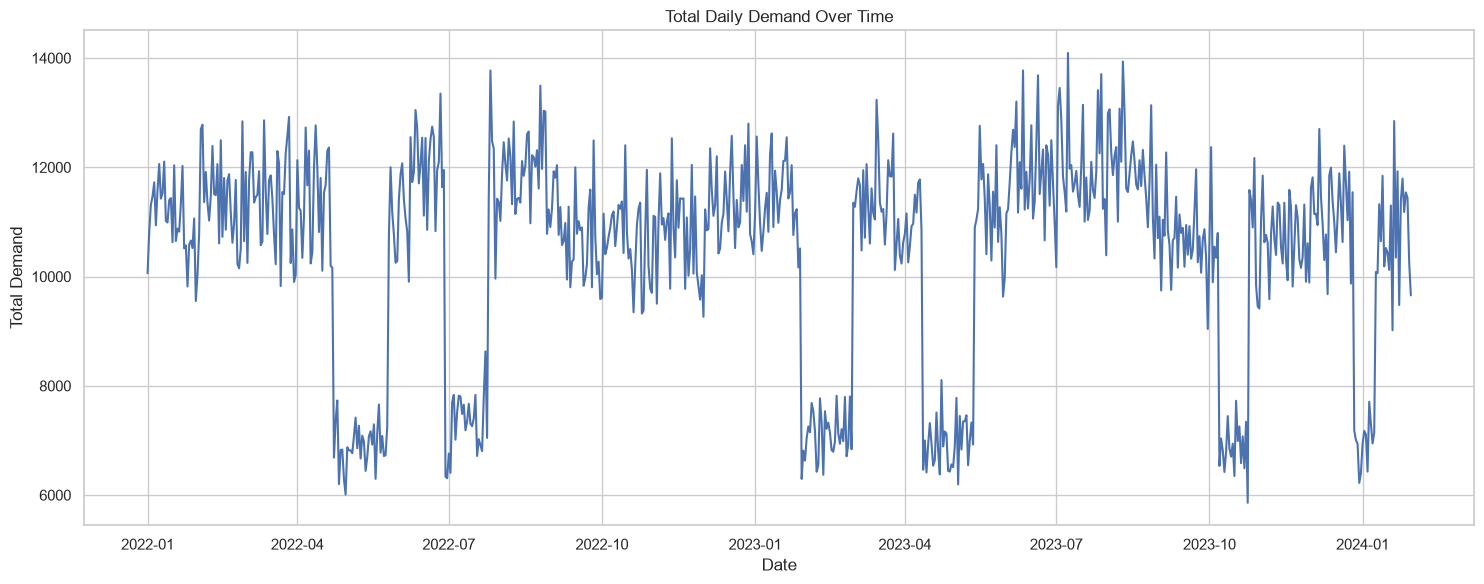

In [8]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["sum"]
)

plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

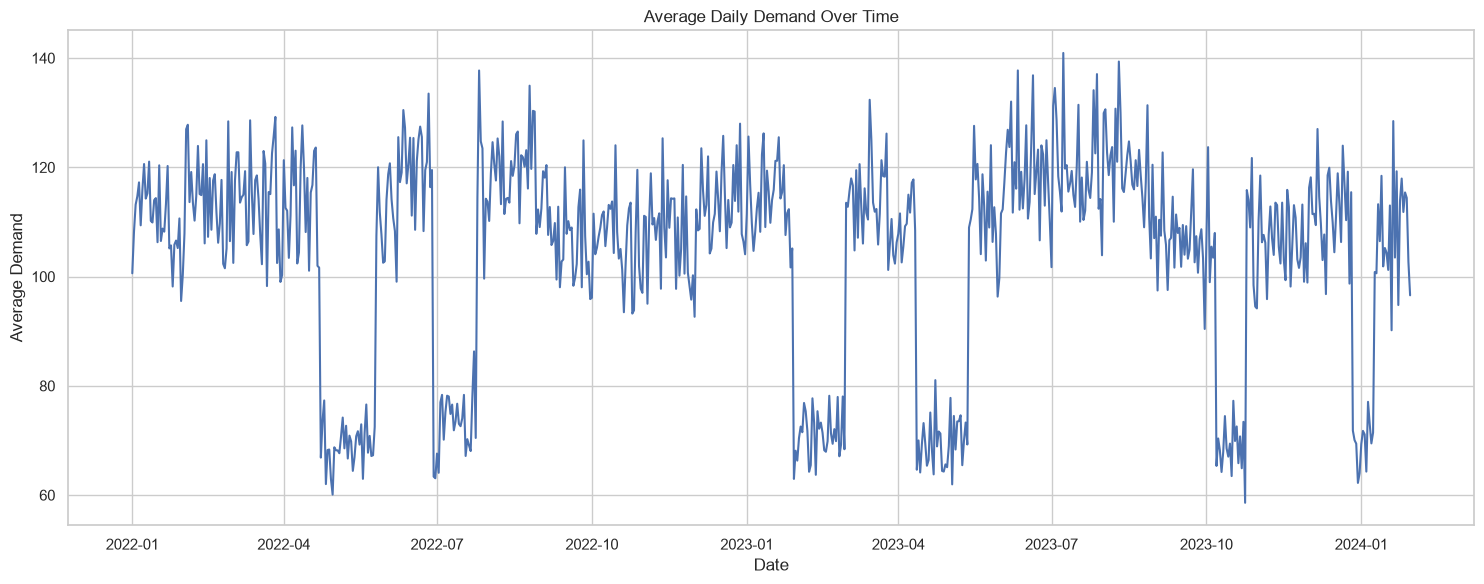

In [9]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["mean"]
)

plt.title("Average Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 4. Rolling Demand

Rolling averages smooth short-term fluctuations and help reveal the underlying
trend.

A 7-day and 30-day rolling average are examined.

In [10]:
daily_demand["Rolling_7_Day"] = (
    daily_demand["mean"]
    .rolling(7)
    .mean()
)

daily_demand["Rolling_30_Day"] = (
    daily_demand["mean"]
    .rolling(30)
    .mean()
)

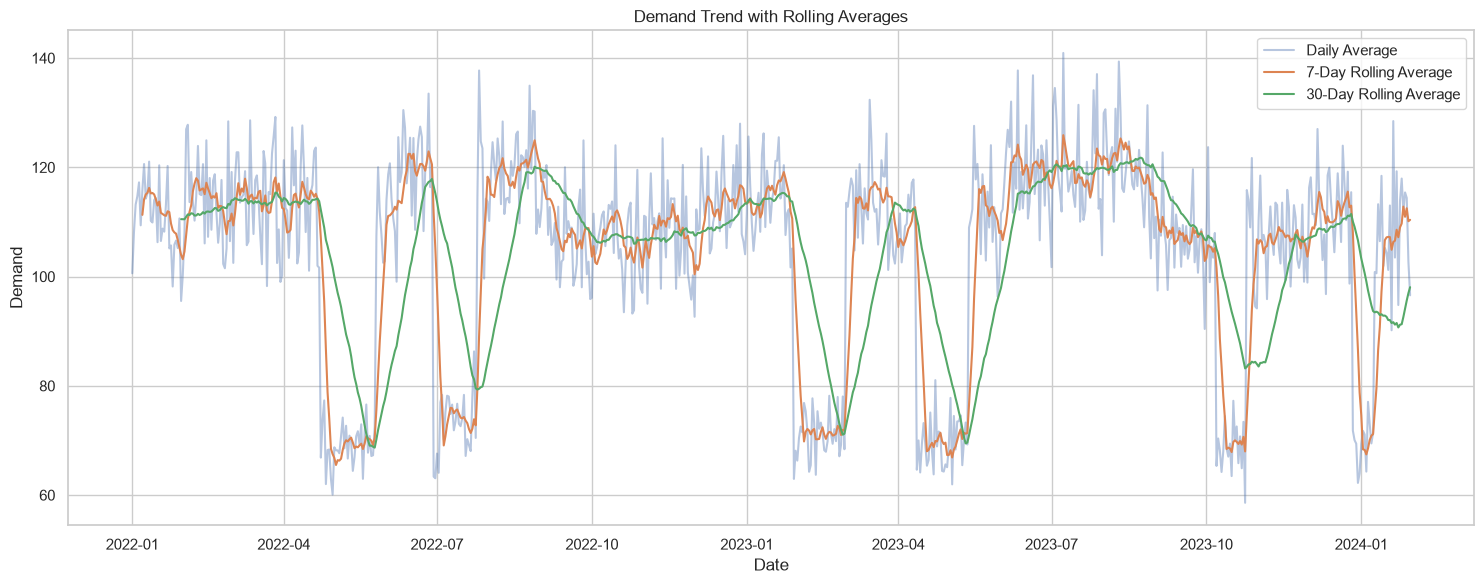

In [11]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["mean"],
    alpha=0.4,
    label="Daily Average"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["Rolling_7_Day"],
    label="7-Day Rolling Average"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["Rolling_30_Day"],
    label="30-Day Rolling Average"
)

plt.title("Demand Trend with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.tight_layout()
plt.show()

## 5. Monthly Demand Pattern

Monthly aggregation helps identify longer-term changes and potential
seasonality.

In [12]:
monthly_demand = (
    df.set_index("Date")["Demand"]
    .resample("ME")
    .agg(["sum", "mean", "std"])
    .reset_index()
)

monthly_demand.head()

,Date,sum,mean,std
0,2022-01-31,341544,110.175484,42.762650
1,2022-02-28,319883,114.243929,44.559262
2,2022-03-31,353173,113.926774,44.580496
3,2022-04-30,305076,101.692000,46.299068
4,2022-05-31,239112,77.132903,40.526684


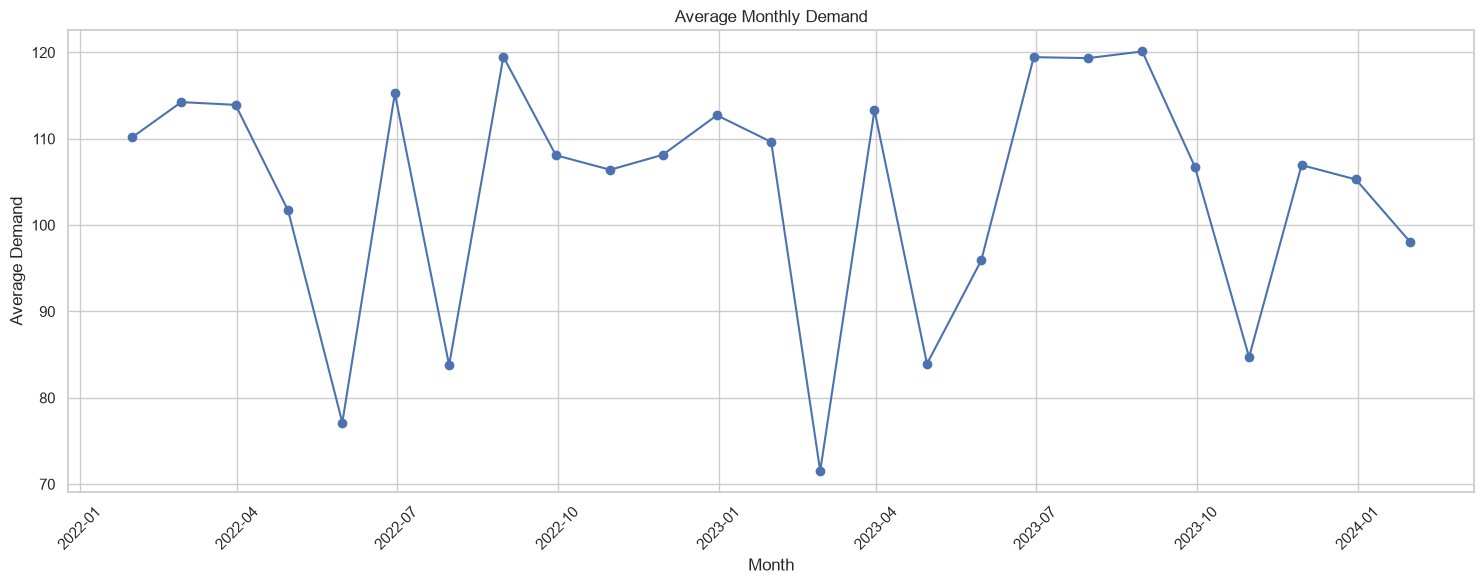

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_demand["Date"],
    monthly_demand["mean"],
    marker="o"
)

plt.title("Average Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Day-of-Week Demand Pattern

Demand may vary across different days of the week.

This can later motivate calendar-based features.

In [14]:
df["DayOfWeek"] = df["Date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_demand = (
    df.groupby("DayOfWeek")["Demand"]
    .agg(["mean", "sum", "std"])
    .reindex(day_order)
)

day_demand

,mean,sum,std
DayOfWeek,,,
Monday,103.423303,1127314,46.479319
Tuesday,103.665229,1129951,46.889936
Wednesday,105.192037,1136074,47.908105
Thursday,104.408333,1127610,46.662997
Friday,104.394444,1127460,46.288416
Saturday,104.484037,1138876,47.409272
Sunday,104.662294,1140819,47.085348


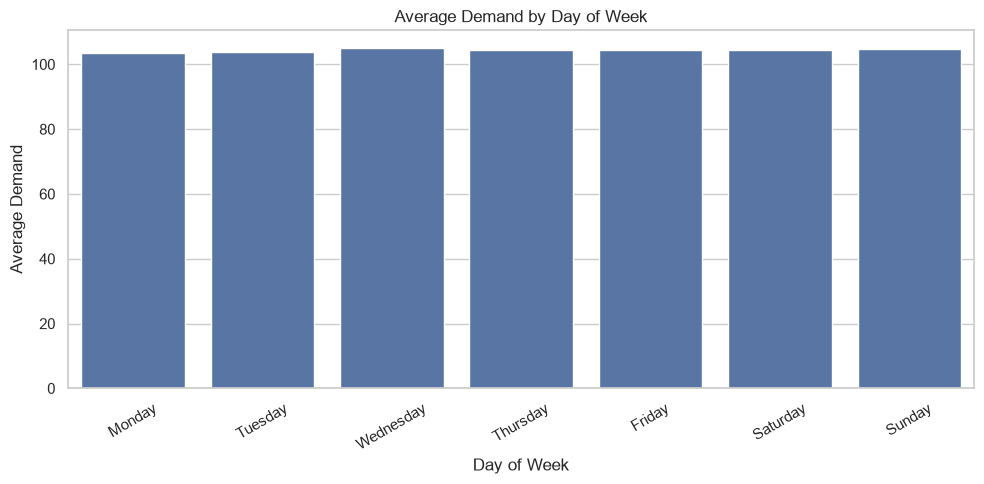

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_demand.index,
    y=day_demand["mean"]
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 7. Monthly Seasonality

We compare average demand across calendar months.

If clear differences exist, month-based features may be useful for the
forecasting model.

In [16]:
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_seasonality = (
    df.groupby(["Month", "MonthName"])["Demand"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

monthly_seasonality

,Month,MonthName,Demand
0,1,January,106.040000
1,2,February,92.882500
2,3,March,113.613871
3,4,April,92.816667
4,5,May,86.521129
5,6,June,117.346000
6,7,July,101.561613
7,8,August,119.803387
8,9,September,107.431500
9,10,October,95.557258


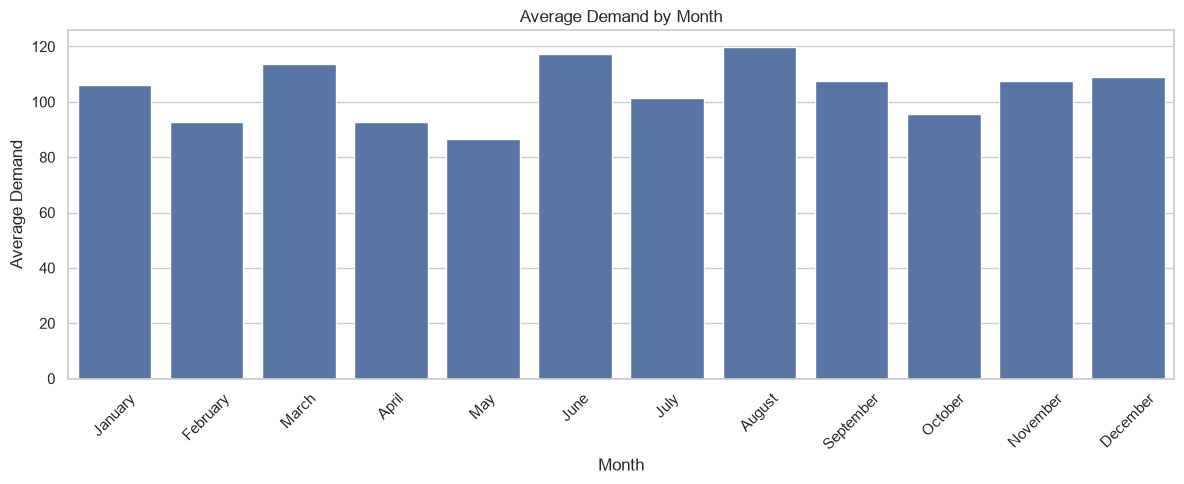

In [17]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_seasonality,
    x="MonthName",
    y="Demand"
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
df["Quarter"] = df["Date"].dt.quarter

quarter_demand = (
    df.groupby("Quarter")["Demand"]
    .agg(["mean", "sum", "std"])
)

quarter_demand

,mean,sum,std
Quarter,,,
1,104.767429,2200116,45.972385
2,98.758626,1797407,49.024329
3,109.622391,2017052,48.694731
4,103.996141,1913529,43.488457


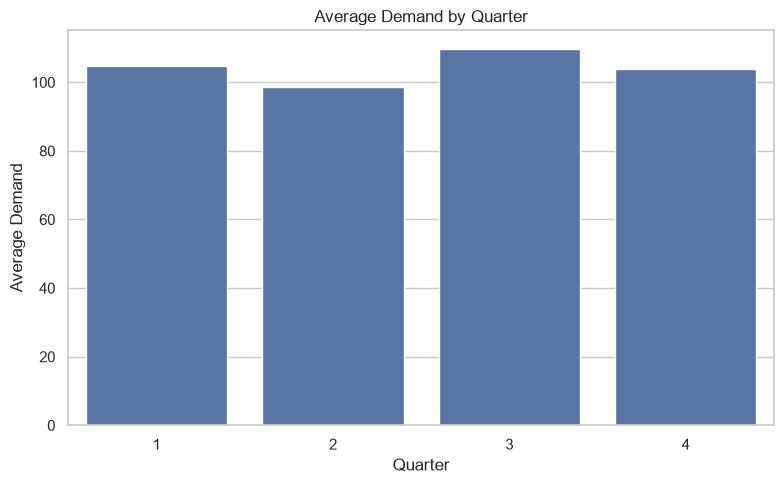

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=quarter_demand.index,
    y=quarter_demand["mean"]
)

plt.title("Average Demand by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 8. Store-Level Demand Analysis

Different stores may have different demand profiles.

We examine:

- Average demand
- Total demand
- Demand variability

In [20]:
store_demand = (
    df.groupby("Store ID")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std"
    )
    .sort_values(
        "Average_Demand",
        ascending=False
    )
)

store_demand

,Average_Demand,Total_Demand,Demand_Std
Store ID,,,
S002,106.938882,1625471,45.608125
S003,106.468684,1618324,47.424239
S005,105.729276,1607085,48.269190
S001,101.814013,1547573,47.131647
S004,100.634934,1529651,45.991886


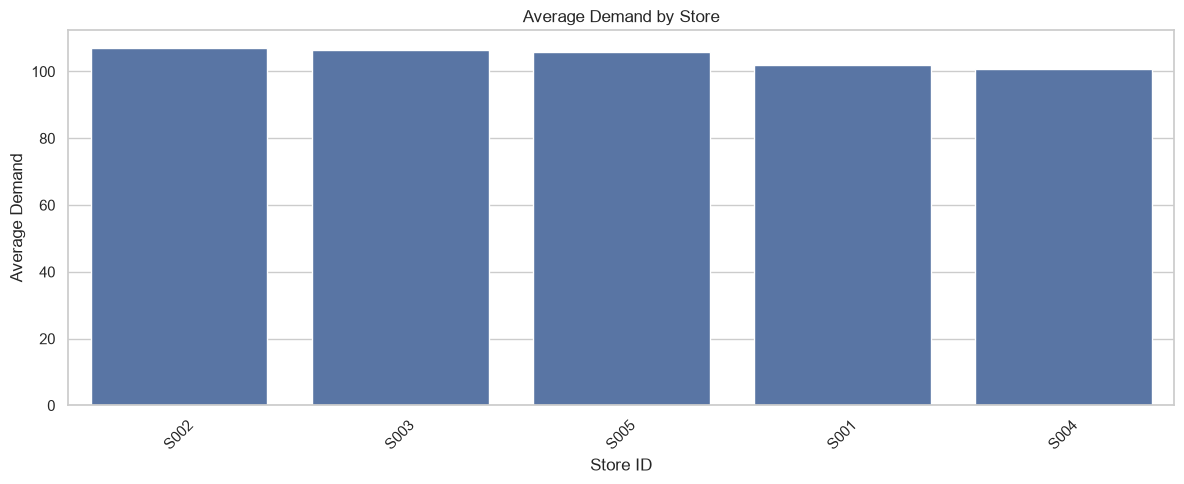

In [21]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=store_demand.index.astype(str),
    y=store_demand["Average_Demand"]
)

plt.title("Average Demand by Store")
plt.xlabel("Store ID")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

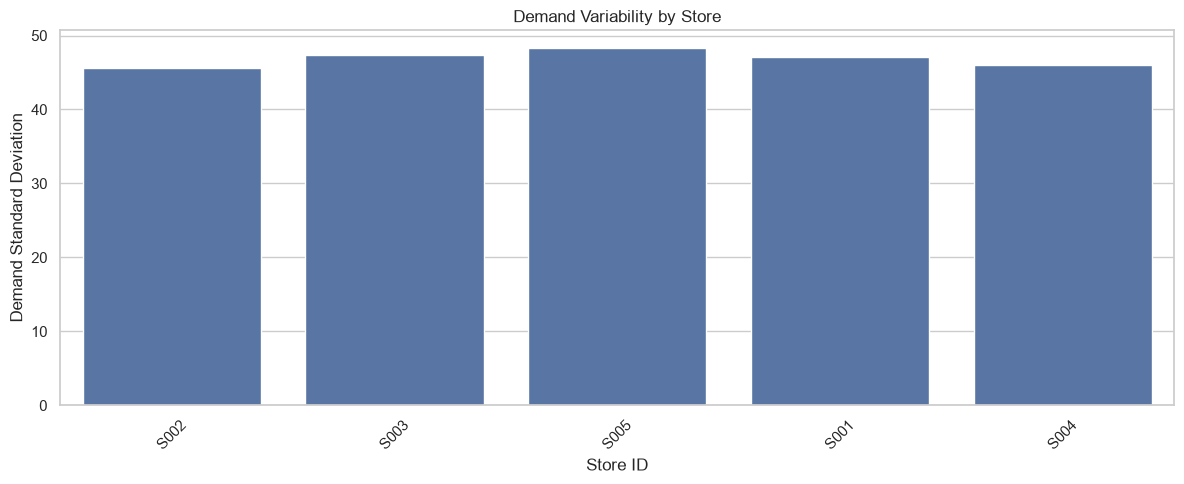

In [22]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=store_demand.index.astype(str),
    y=store_demand["Demand_Std"]
)

plt.title("Demand Variability by Store")
plt.xlabel("Store ID")
plt.ylabel("Demand Standard Deviation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Product-Level Demand Analysis

Product demand can vary significantly.

We identify high-demand and low-demand products and examine demand
variability.

In [23]:
product_demand = (
    df.groupby("Product ID")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std"
    )
    .sort_values(
        "Average_Demand",
        ascending=False
    )

)

product_demand.head(15)

,Average_Demand,Total_Demand,Demand_Std
Product ID,,,
P0009,118.506316,450324,46.087811
P0013,116.025000,440895,49.937341
P0004,115.396053,438505,48.157642
P0007,115.023421,437089,48.938656
P0002,112.066579,425853,48.796185
P0010,111.069474,422064,49.135104
P0001,109.591316,416447,46.716978
P0006,107.722368,409345,48.013768
P0005,107.520526,408578,45.623828


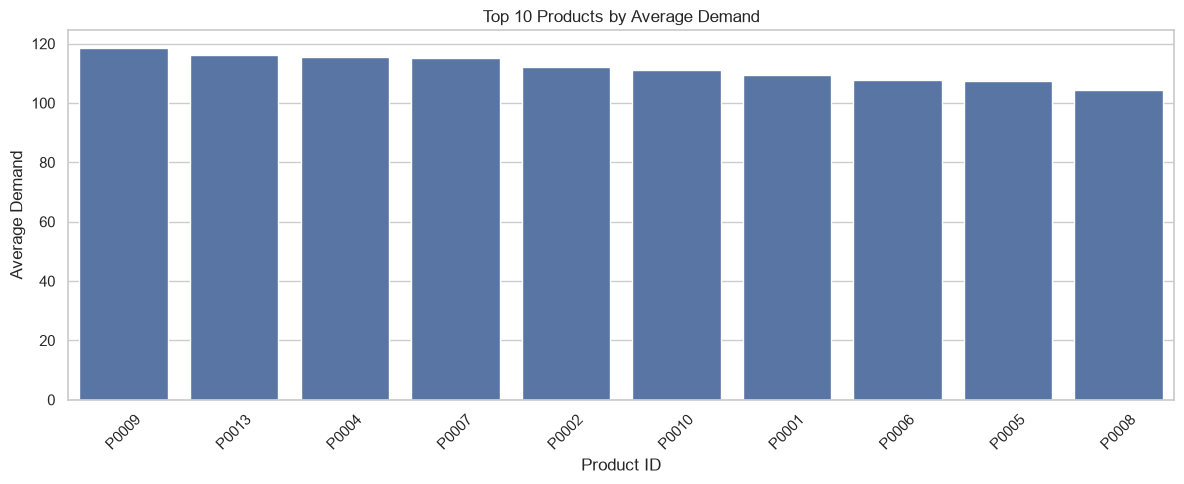

In [24]:
top_products = product_demand.head(10)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=top_products.index.astype(str),
    y=top_products["Average_Demand"]
)

plt.title("Top 10 Products by Average Demand")
plt.xlabel("Product ID")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
category_demand = (
    df.groupby("Category")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std"
    )
    .sort_values(
        "Average_Demand",
        ascending=False
    )
)

category_demand

,Average_Demand,Total_Demand,Demand_Std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Electronics,97.482018,889036,40.557859
Toys,92.606955,985338,46.170390
Furniture,73.581140,1006590,32.336141


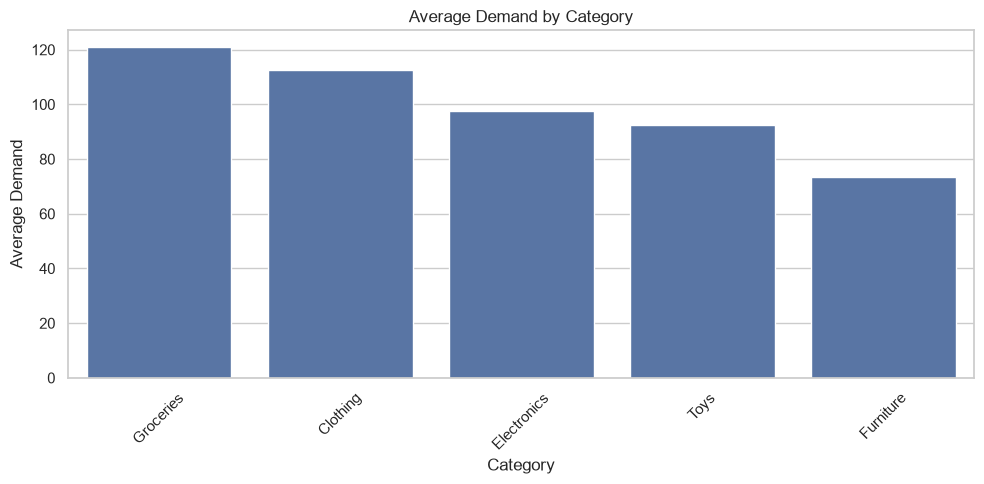

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_demand.reset_index(),
    x="Category",
    y="Average_Demand"
)

plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
region_demand = (
    df.groupby("Region")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std"
    )
    .sort_values(
        "Average_Demand",
        ascending=False
    )
)

region_demand

,Average_Demand,Total_Demand,Demand_Std
Region,,,
South,106.938882,1625471,45.608125
East,106.468684,1618324,47.424239
North,103.771645,3154658,47.743177
West,100.634934,1529651,45.991886


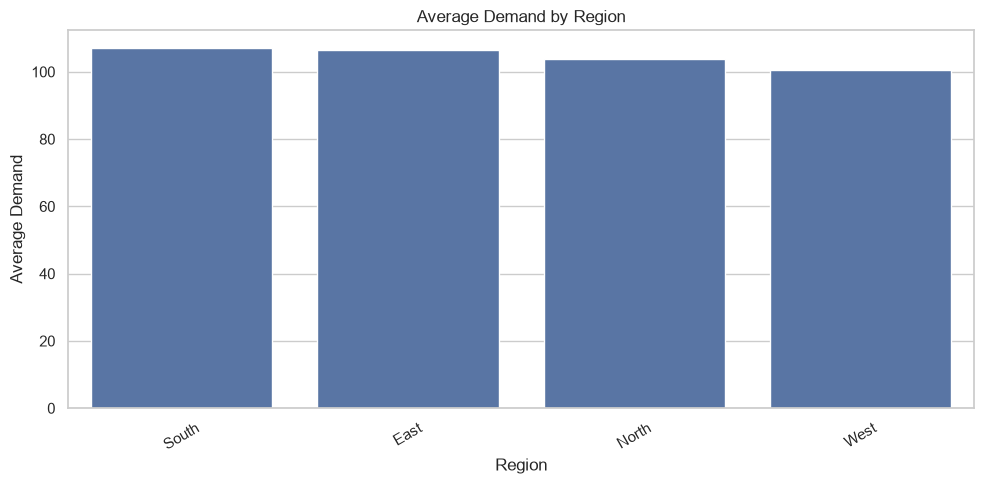

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=region_demand.reset_index(),
    x="Region",
    y="Average_Demand"
)

plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 10. Promotion and Demand

Promotions may significantly influence retail demand.

We compare demand during promotional and non-promotional observations.

In [29]:
promotion_demand = (
    df.groupby("Promotion")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std",
        Count="count"
    )
)

promotion_demand

,Average_Demand,Total_Demand,Demand_Std,Count
Promotion,,,,
0,95.026843,4846369,40.654269,51000
1,123.269400,3081735,52.900712,25000


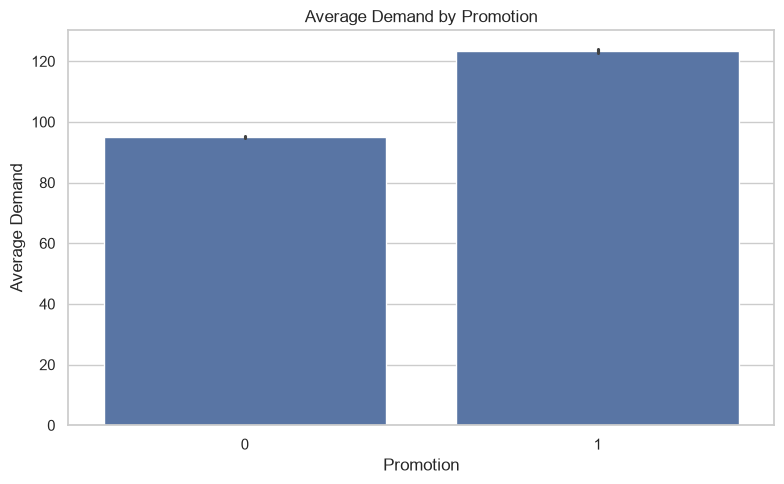

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Promotion",
    y="Demand",
    estimator="mean"
)

plt.title("Average Demand by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 11. Discount and Demand

Discount percentage may influence demand.

We examine the relationship between discount and demand.

In [32]:
discount_bins = pd.cut(
    df["Discount"],
    bins=5
)

discount_demand = (
    df.groupby(discount_bins, observed=True)["Demand"]
    .agg(["mean", "count"])
)

discount_demand

,mean,count
Discount,,
"(-0.025, 5.0]",94.844789,34044
"(5.0, 10.0]",102.767834,23298
"(10.0, 15.0]",123.575981,6245
"(15.0, 20.0]",124.065256,6191
"(20.0, 25.0]",122.967374,6222


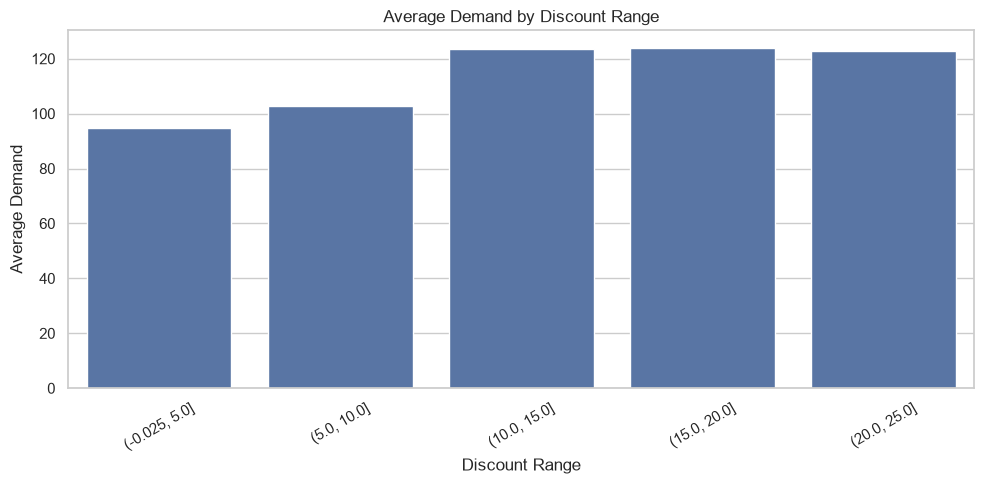

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=discount_demand.index.astype(str),
    y=discount_demand["mean"]
)

plt.title("Average Demand by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 12. Price and Demand

Price is another potential demand-driving variable.

We investigate the relationship between price and demand.

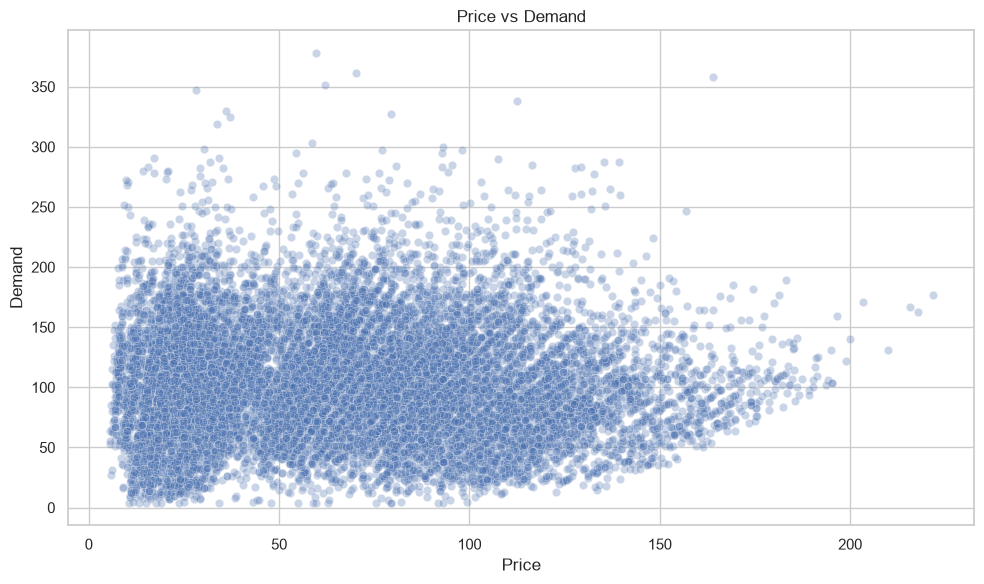

In [34]:
sample_df = df.sample(
    min(15000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Price",
    y="Demand",
    alpha=0.3
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

In [35]:
print(
    "Price-Demand correlation:",
    df["Price"].corr(df["Demand"])
)

Price-Demand correlation: -0.02346082195720526


## 13. Competitor Pricing

Competitor pricing may influence retail demand.

We examine its relationship with demand.

In [36]:
print(
    "Competitor Pricing-Demand correlation:",
    df["Competitor Pricing"].corr(df["Demand"])
)

Competitor Pricing-Demand correlation: -0.023036445032016524


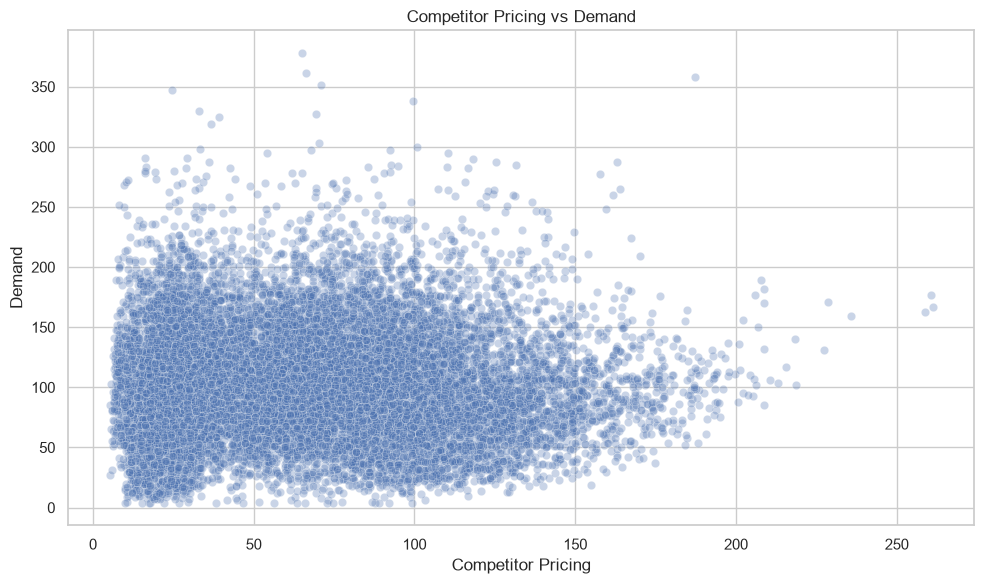

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Competitor Pricing",
    y="Demand",
    alpha=0.3
)

plt.title("Competitor Pricing vs Demand")
plt.xlabel("Competitor Pricing")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 14. Inventory and Demand

Inventory is important for the inventory optimization component.

However, we must distinguish between:

- Inventory available before a forecast
- Inventory observed after demand occurs

This analysis helps us understand the relationship, but does not mean that
inventory should automatically be used as a forecasting feature.

In [38]:
print(
    "Inventory-Demand correlation:",
    df["Inventory Level"].corr(df["Demand"])
)

Inventory-Demand correlation: 0.12661807535498742


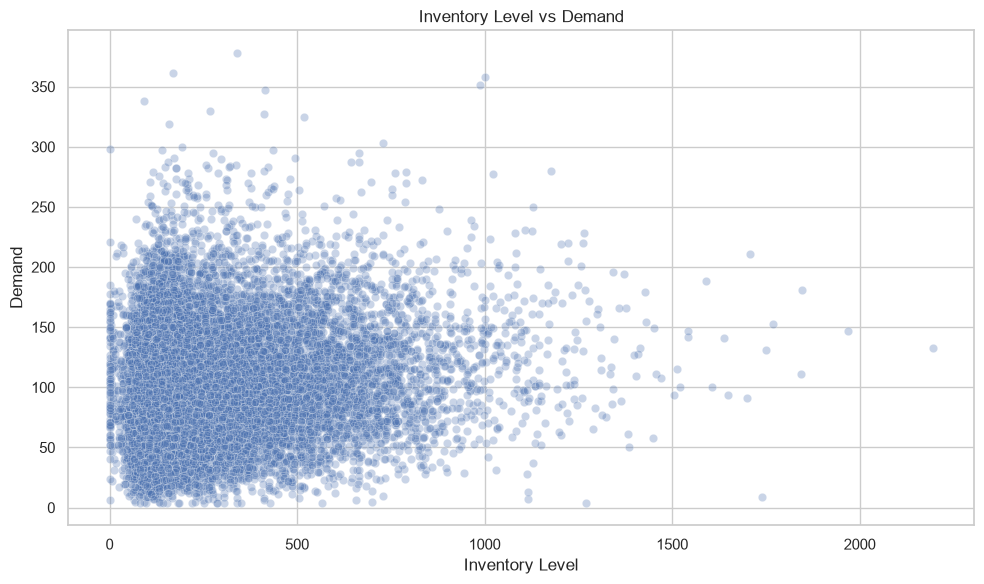

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Inventory Level",
    y="Demand",
    alpha=0.3
)

plt.title("Inventory Level vs Demand")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 15. Units Sold and Demand

`Units Sold` requires special attention because actual sales may be closely
related to realized demand.

A very strong relationship may indicate that using `Units Sold` directly as a
future forecasting feature would introduce target leakage.

We therefore investigate the relationship before feature engineering.

In [40]:
print(
    "Units Sold-Demand correlation:",
    df["Units Sold"].corr(df["Demand"])
)

Units Sold-Demand correlation: 0.8334214303439765


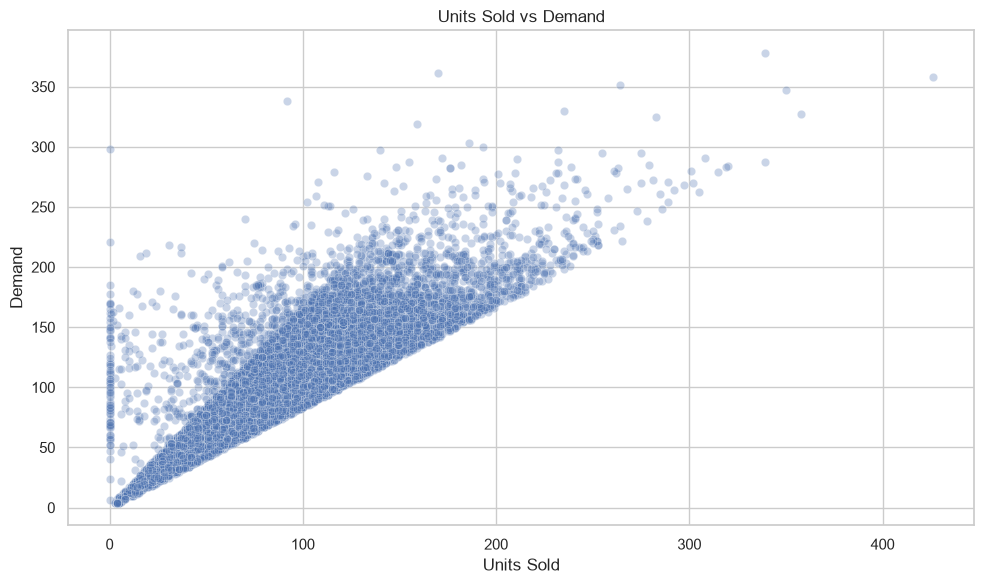

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Units Sold",
    y="Demand",
    alpha=0.3
)

plt.title("Units Sold vs Demand")
plt.xlabel("Units Sold")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

In [42]:
print(
    "Units Ordered-Demand correlation:",
    df["Units Ordered"].corr(df["Demand"])
)

Units Ordered-Demand correlation: 0.5119626250855662


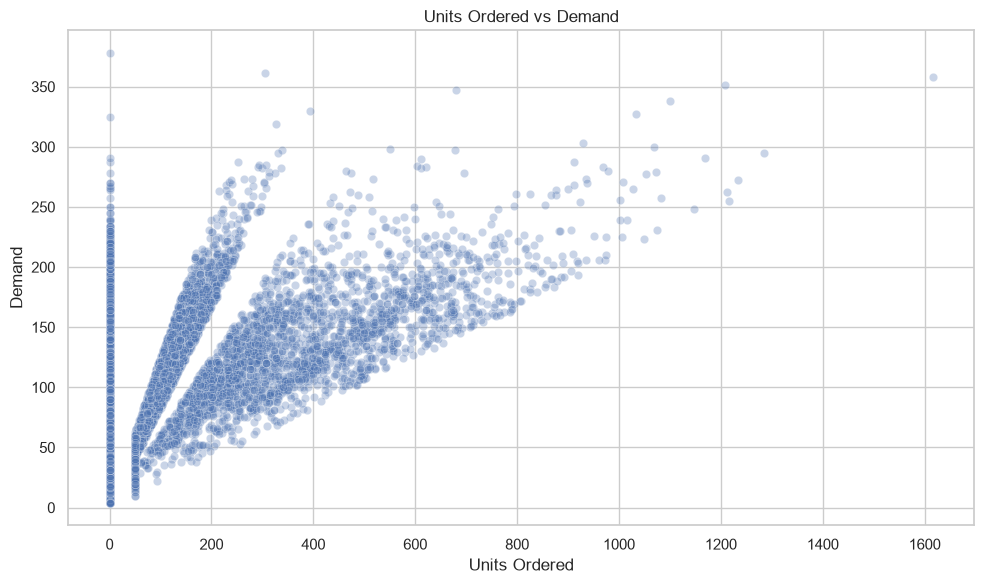

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Units Ordered",
    y="Demand",
    alpha=0.3
)

plt.title("Units Ordered vs Demand")
plt.xlabel("Units Ordered")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

In [44]:
weather_demand = (
    df.groupby("Weather Condition")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std"
    )
    .sort_values(
        "Average_Demand",
        ascending=False
    )
)

weather_demand

,Average_Demand,Total_Demand,Demand_Std
Weather Condition,,,
Sunny,115.167189,2646542,51.092824
Cloudy,105.404064,2567643,46.645370
Rainy,95.106743,1664368,42.642277
Snowy,94.045789,1049551,39.520209


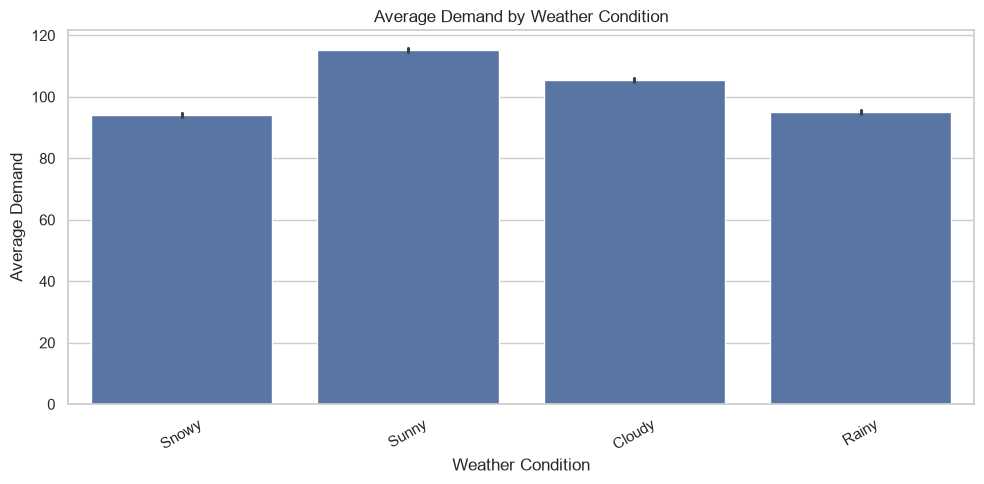

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Weather Condition",
    y="Demand",
    estimator="mean"
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [46]:
seasonality_demand = (
    df.groupby("Seasonality")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std"
    )
)

seasonality_demand

,Average_Demand,Total_Demand,Demand_Std
Seasonality,,,
Autumn,103.422967,1882298,41.974885
Spring,97.703098,1797737,46.038644
Summer,112.855380,2076539,51.930652
Winter,103.406190,2171530,46.174414


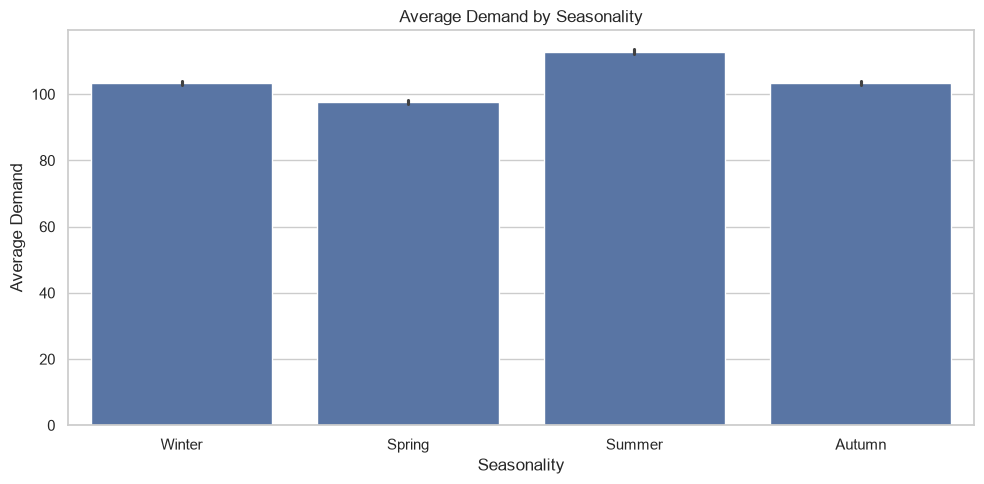

In [47]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Seasonality",
    y="Demand",
    estimator="mean"
)

plt.title("Average Demand by Seasonality")
plt.xlabel("Seasonality")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

In [48]:
epidemic_demand = (
    df.groupby("Epidemic")["Demand"]
    .agg(
        Average_Demand="mean",
        Total_Demand="sum",
        Demand_Std="std",
        Count="count"
    )
)

epidemic_demand

,Average_Demand,Total_Demand,Demand_Std,Count
Epidemic,,,,
0,112.856743,6861690,44.639548,60800
1,70.158816,1066414,39.991331,15200


## 16. Numerical Feature Correlation

We examine correlations between numerical variables and demand.

Correlation is used only as an exploratory measure and does not establish
causality.

In [49]:
numerical_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Demand"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Demand
Inventory Level,1.000000,0.234590,-0.034698,-0.036673,-0.000678,-0.034754,0.126618
Units Sold,0.234590,1.000000,0.433943,-0.014506,0.183523,-0.013989,0.833421
Units Ordered,-0.034698,0.433943,1.000000,0.044980,0.172972,0.045235,0.511963
Price,-0.036673,-0.014506,0.044980,1.000000,-0.094136,0.976648,-0.023461
Discount,-0.000678,0.183523,0.172972,-0.094136,1.000000,-0.092066,0.224723
Competitor Pricing,-0.034754,-0.013989,0.045235,0.976648,-0.092066,1.000000,-0.023036
Demand,0.126618,0.833421,0.511963,-0.023461,0.224723,-0.023036,1.000000


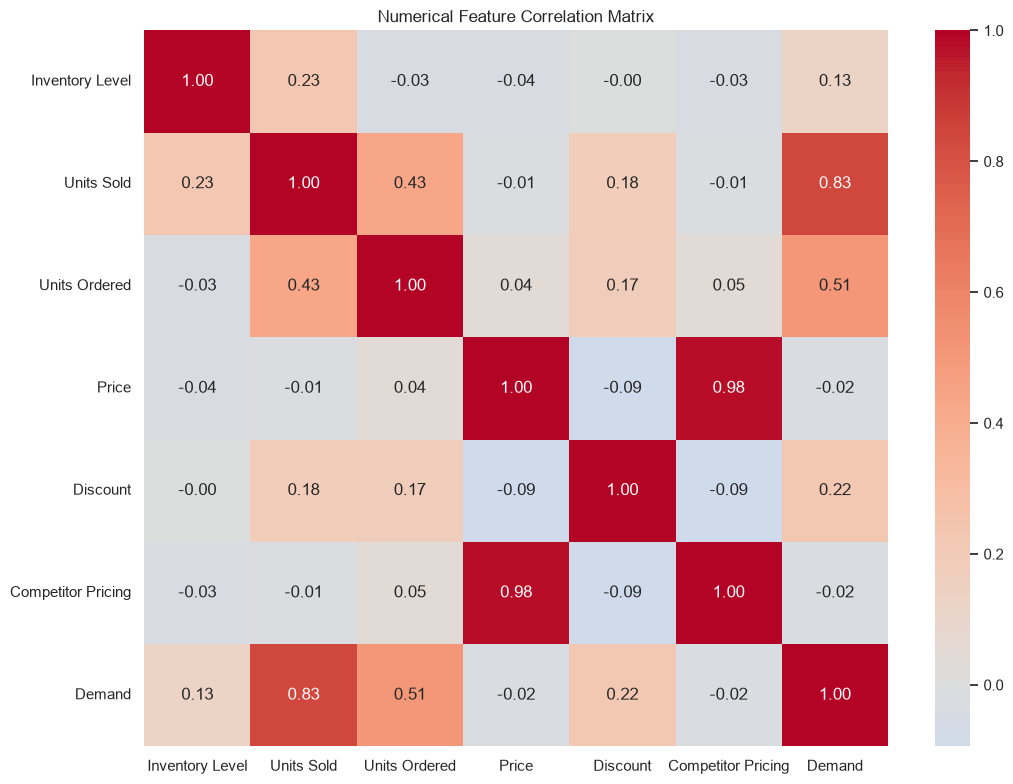

In [50]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## 17. Demand Volatility

Inventory optimization depends not only on average demand but also on demand
uncertainty.

We calculate the coefficient of variation:

CV = Standard Deviation / Mean

Higher CV indicates more volatile demand.

In [51]:
product_volatility = (
    df.groupby("Product ID")["Demand"]
    .agg(
        Mean_Demand="mean",
        Std_Demand="std"
    )
)

product_volatility["CV"] = (
    product_volatility["Std_Demand"] /
    product_volatility["Mean_Demand"]
)

product_volatility = product_volatility.sort_values(
    "CV",
    ascending=False
)

product_volatility.head(15)

,Mean_Demand,Std_Demand,CV
Product ID,,,
P0017,92.268421,44.254071,0.479623
P0020,84.433421,39.696947,0.470157
P0014,95.877632,44.430241,0.463406
P0018,99.264474,45.749611,0.460886
P0016,100.756316,46.411025,0.460626
P0015,102.491579,47.096809,0.459519
P0012,91.372368,41.818942,0.457676
P0003,103.995263,46.690876,0.448971
P0019,97.882632,43.761371,0.447080


In [52]:
store_product_stats = (
    df.groupby(
        ["Store ID", "Product ID"]
    )["Demand"]
    .agg(
        Mean_Demand="mean",
        Std_Demand="std"
    )
)

store_product_stats["CV"] = (
    store_product_stats["Std_Demand"] /
    store_product_stats["Mean_Demand"]
)

store_product_stats.sort_values(
    "CV",
    ascending=False
).head(20)

Mean_Demand  Std_Demand        CV
Store ID Product ID                                   
S005     P0017         91.473684   47.113345  0.515048
S003     P0006         93.205263   47.343111  0.507945
S001     P0015         91.251316   46.224448  0.506562
         P0013         92.792105   46.939862  0.505861
S002     P0007         91.865789   46.373950  0.504801
S003     P0005         91.594737   46.092437  0.503221
S001     P0006         91.978947   46.013798  0.500264
         P0017         94.161842   46.993638  0.499073
S005     P0016         94.884211   47.253693  0.498014
S002     P0002         93.938158   46.486261  0.494860
         P0017         92.927632   45.722469  0.492022
S005     P0020         92.035526   45.157199  0.490650
         P0003         92.948684   45.093447  0.485143
S003     P0001         91.439474   43.643502  0.477294
S004     P0003         74.743421   34.275620  0.458577
         P0008         75.105263   33.997202  0.452661
S001     P0011         74.253947   33.306221  0.448545
S004     P0020         73.546053   32.976464  0.448378
S001     P0019         73.480263   32.646219  0.444286
S005     P0019         72.822368   32.255302  0.442931

## 18. Demand Autocorrelation

Autocorrelation measures whether demand at one point in time is related to
demand at previous time points.

Strong autocorrelation would support the use of lag-based features such as:

- Previous-day demand
- Previous-week demand
- Rolling average demand
- Rolling demand volatility

In [53]:
overall_daily_demand = (
    df.groupby("Date")["Demand"]
    .mean()
    .sort_index()
)

for lag in [1, 2, 3, 7, 14, 30]:
    correlation = overall_daily_demand.autocorr(
        lag=lag
    )
    
    print(
        f"Lag {lag:>2} day correlation: "
        f"{correlation:.4f}"
    )

Lag  1 day correlation: 0.8291
Lag  2 day correlation: 0.7838
Lag  3 day correlation: 0.7231
Lag  7 day correlation: 0.5792
Lag 14 day correlation: 0.2995
Lag 30 day correlation: -0.1607


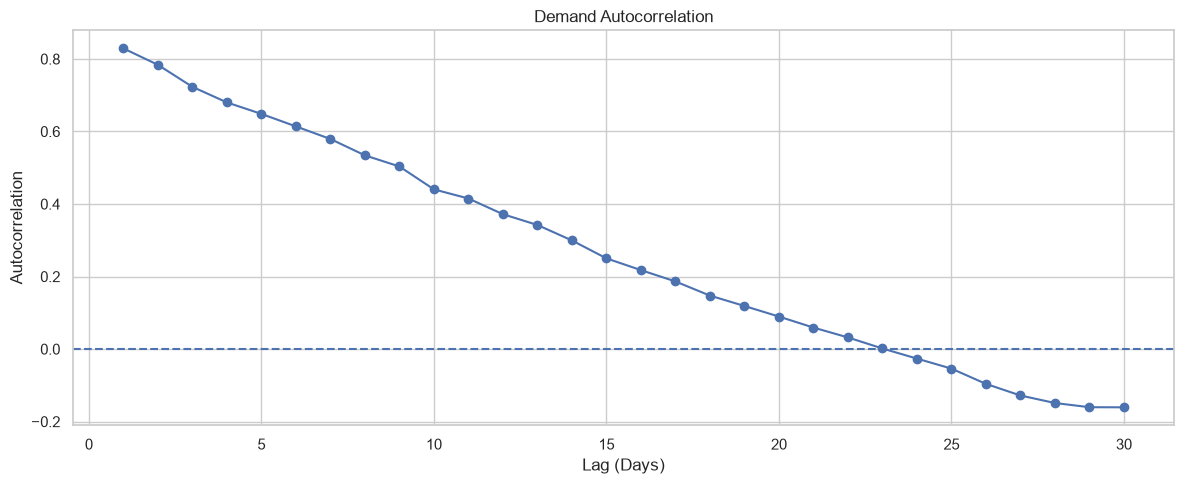

In [54]:
lags = range(1, 31)

autocorrelations = [
    overall_daily_demand.autocorr(lag=lag)
    for lag in lags
]

plt.figure(figsize=(12, 5))

plt.plot(
    lags,
    autocorrelations,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Demand Autocorrelation")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

## 19. Store-Level Demand Trends

We examine whether stores exhibit different temporal demand patterns.

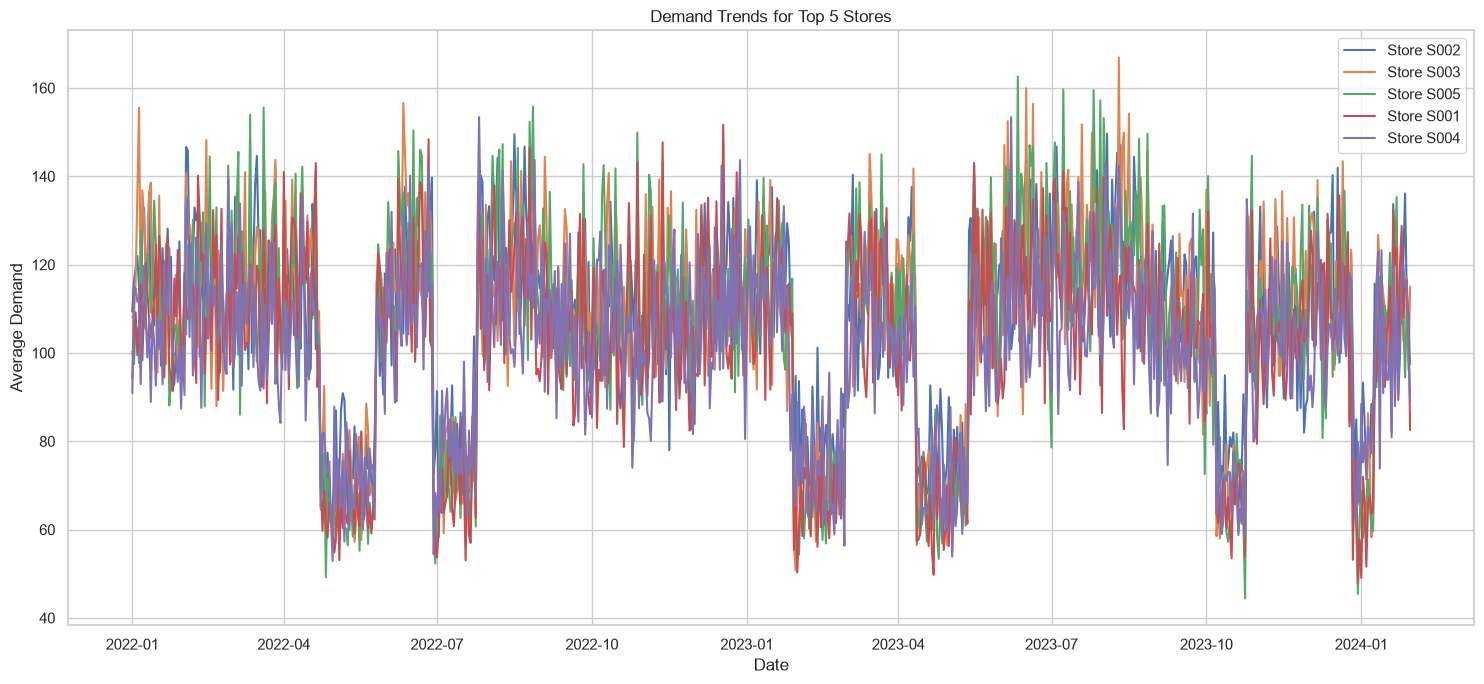

In [55]:
store_daily = (
    df.groupby(
        ["Date", "Store ID"]
    )["Demand"]
    .mean()
    .reset_index()
)

top_stores = (
    df.groupby("Store ID")["Demand"]
    .mean()
    .nlargest(5)
    .index
)

plt.figure(figsize=(15, 7))

for store in top_stores:
    store_data = store_daily[
        store_daily["Store ID"] == store
    ]
    
    plt.plot(
        store_data["Date"],
        store_data["Demand"],
        label=f"Store {store}"
    )

plt.title("Demand Trends for Top 5 Stores")
plt.xlabel("Date")
plt.ylabel("Average Demand")

plt.legend()

plt.tight_layout()
plt.show()

## 20. Calendar Demand Pattern

A weekday-month heatmap can reveal recurring calendar patterns that may be
useful for feature engineering.

In [56]:
calendar_demand = (
    df.groupby(
        ["Month", "DayOfWeek"]
    )["Demand"]
    .mean()
    .unstack()
)

calendar_demand = calendar_demand.reindex(
    columns=day_order
)

calendar_demand

DayOfWeek,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Month,,,,,,,
1,103.934667,102.695714,108.135833,107.489167,107.381667,111.480769,102.399286
2,92.633750,89.370000,95.750000,92.765000,92.286250,92.640000,94.732500
3,109.191250,112.290000,113.300000,113.202000,113.987778,117.676250,115.950000
4,97.021250,96.848750,93.812500,89.295000,93.166667,86.122000,94.828889
5,85.044000,85.220000,81.976667,86.421250,89.213750,88.972500,89.668889
6,119.096250,119.908750,115.388889,109.604000,119.864444,115.593750,123.831250
7,104.048889,103.116250,104.165000,101.313750,96.873333,100.237000,101.739000
8,114.022222,121.235000,120.262000,122.322222,116.978750,120.361250,123.377500
9,109.132500,106.933750,104.873750,107.928889,107.822000,106.617778,108.653750


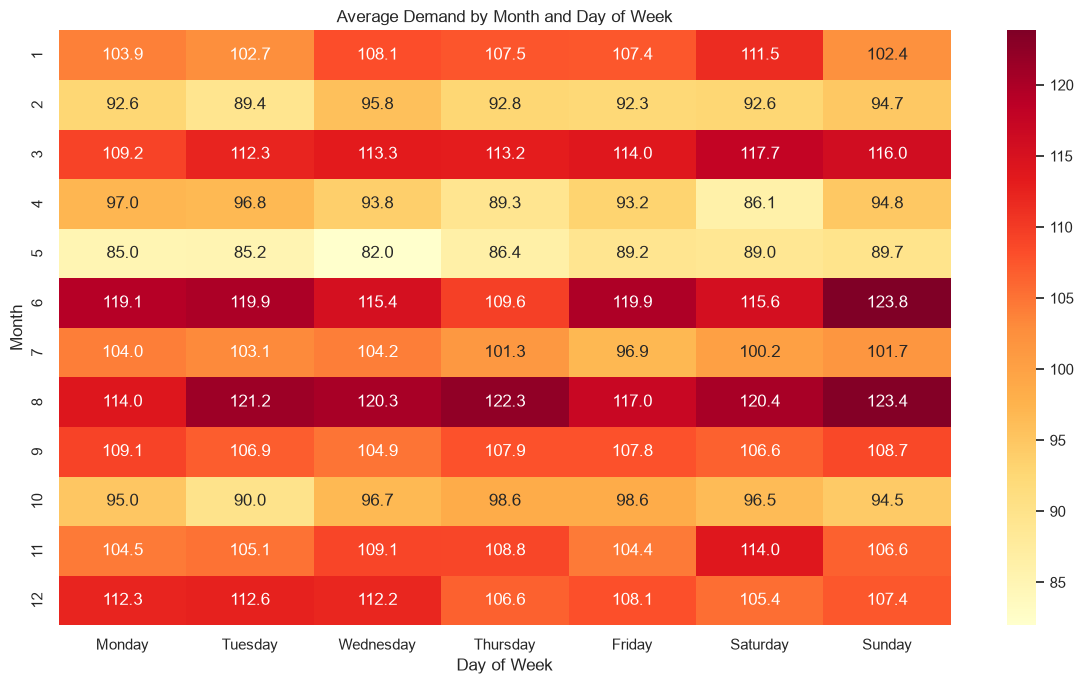

In [57]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    calendar_demand,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Average Demand by Month and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

## 21. Strongest Numerical Relationships with Demand

In [58]:
demand_correlations = (
    df[numerical_columns]
    .corr()["Demand"]
    .drop("Demand")
    .sort_values(
        key=abs,
        ascending=False
    )
)

demand_correlations

Units Sold            0.833421
Units Ordered         0.511963
Discount              0.224723
Inventory Level       0.126618
Price                -0.023461
Competitor Pricing   -0.023036
Name: Demand, dtype: float64

In [59]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Average Demand",
        "Demand Std Dev",
        "Minimum Demand",
        "Maximum Demand",
        "Unique Stores",
        "Unique Products",
        "Unique Categories",
        "Unique Regions",
        "Unique Dates",
        "Price-Demand Correlation",
        "Inventory-Demand Correlation",
        "Units Sold-Demand Correlation",
        "Units Ordered-Demand Correlation"
    ],
    "Value": [
        df["Demand"].mean(),
        df["Demand"].std(),
        df["Demand"].min(),
        df["Demand"].max(),
        df["Store ID"].nunique(),
        df["Product ID"].nunique(),
        df["Category"].nunique(),
        df["Region"].nunique(),
        df["Date"].nunique(),
        df["Price"].corr(df["Demand"]),
        df["Inventory Level"].corr(df["Demand"]),
        df["Units Sold"].corr(df["Demand"]),
        df["Units Ordered"].corr(df["Demand"])
    ]
})

eda_summary

,Metric,Value
0,Average Demand,104.317158
1,Demand Std Dev,46.964801
2,Minimum Demand,4.000000
3,Maximum Demand,430.000000
4,Unique Stores,5.000000
5,Unique Products,20.000000
6,Unique Categories,5.000000
7,Unique Regions,4.000000
8,Unique Dates,760.000000
9,Price-Demand Correlation,-0.023461


# 22. EDA Conclusions

## Demand Behaviour

The analysis examined the distribution, variability, and temporal behaviour
of retail demand.

## Time-Series Characteristics

Daily, weekly, monthly, and calendar-based demand patterns were investigated.
Autocorrelation was also examined to determine whether historical demand may
be useful for forecasting.

## Store and Product Differences

Demand varies across stores and products. Therefore, store and product
identifiers may be important components of the forecasting strategy.

## External Factors

The effects of promotion, discount, price, competitor pricing, weather,
seasonality, and epidemic conditions were investigated.

## Inventory

Inventory-demand relationships were examined separately because inventory
information must be aligned correctly with the forecast timestamp.

## Potential Leakage

Variables such as:

- Units Sold
- Units Ordered
- Inventory Level

must not automatically be treated as future forecasting inputs. Their use
will depend on what information is available at the time the forecast is
generated.

## Next Step

The next notebook will convert the insights from this EDA into a machine
learning-ready feature set.

### Notebook 04 — Feature Engineering and Dataset Preparation

The next stage will introduce:

- Calendar features
- Lag features
- Rolling statistics
- Store-level features
- Product-level features
- Price/discount features
- Promotion features
- Proper time-based train/validation/test splitting
- Feature selection
- Final ML-ready datasets